# CSCN8020 Deep Q Learning Pong Game (DQN Pong Game)

In this notebook, a Deep Q-Network (DQN) agent to play pong is implemented. Since Pong uses image-based observations, we can't use tabular Q-learning. Instead, the Q-function is approximated using a Convolutional Neural Network (CNN).

We preprocess frames, stack multiple frames to capture motion, and train the agent using experience replay and a target network.

Different hyperparameters are looked at and evaluated and visualize the agent playing the game.

# 1. Imports and Environment Setup

Imports for all the necessary libraries including:
- Gym
- Pytorch
- Numpy

Two environments will be created:
1. Training Environment (No rendering will happen for easy testing)
2. Rendering Environment (used after training to visualize performance)
A separate notebook will be provided that will only do the training env but also have the rendering so an idea of how the training can also be seen

PongDeterministic-v4 environment is used as required in the assignment

In [1]:
import gymnasium  as gym
import ale_py
import re

import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import logging
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = gym.make("ALE/Pong-v5", render_mode="human")
render_env = gym.make("ALE/Pong-v5", render_mode="human")

action_size = env.action_space.n

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)


logger = logging.getLogger("DQN")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

handler = logging.FileHandler("logs/dqn.log", mode="w")
logger.addHandler(handler)

# 2. Frame Preprocessing and Stacking

Raw frames from Pong are large (210x160x3) and contain redundant info.

The preprocessing functions are used to:
- Crop unnecessary parts of the image
- Downscale Resolution
- Convert to grayscale
- Normalize pixel values

We then stack 4 consecutive frames together. This is essential because a single frame deos not capture motion like the balls direction.

In [2]:
def process_frame(img):
    img = img[30:-12, :, :]
    img = img[::2, ::2]
    img = np.mean(img, axis=2).astype(np.uint8)
    img = (img - 128) / 128 - 1
    return img.reshape(84, 80, 1)

def stack_frames(frames, state, is_new):
    frame = process_frame(state)

    if is_new:
        frames = deque([frame]*4, maxlen=4)
    else:
        frames.append(frame)

    return np.concatenate(frames, axis=2), frames

# 3. Experience Replay Buffer

Deep Q-learning suffers from instability if we train on consectuive samples.
To fix this, we store experiences and sample randomly.

Each experience will consist of:
(state, action, reward, next_state, done)

This imrpoves the stability and learning efficiency

In [3]:
class ReplayBuffer:
    def __init__(self, size):
        self.buffer = deque(maxlen=size)

    def add(self, exp):
        self.buffer.append(exp)

    def sample(self, batch):
        batch = random.sample(self.buffer, batch)
        s, a, r, ns, d = zip(*batch)
        return np.array(s), a, r, np.array(ns), d

    def __len__(self):
        return len(self.buffer)


# 4. Deep Q-Network (CNN)

We use a Convolutional Neural Network to approximate the Q-function

Input:
- 4 stacked frames (84x80x4)

Output:
- Q-values for each action

The convolutional layers extract spatial features, while fully connected layers map these features to action values.

In [4]:
class DQN(nn.Module):
    def __init__(self, actions):
        super(DQN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4,32,8,4),
            nn.ReLU(),
            nn.Conv2d(32,64,4,2),
            nn.ReLU(),
            nn.Conv2d(64,64,3,1),
            nn.ReLU(),

        )

        self.fc = nn.Sequential(
            nn.Linear(64*7*6, 512),
            nn.ReLU(),
            nn.Linear(512, actions)
        )

    def forward(self, x):
        x = x.permute(0,3,1,2)
        x = self.conv(x)
        x = x.reshape(x.shape[0], -1)
        return self.fc(x)


# 5. DQN Agent

The agent:
- Selects actions using ε-greedy policy
- Stores experiences in replay buffer
- Learns using Bellman equation updates
- Uses a target network fro stability

The target network prevents instability caused by constantly changing targets

In [5]:
class Agent:
    def __init__(self, actions):
        self.q_net = DQN(actions).to(device)
        self.target_net = DQN(actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=1e-4)
        self.memory = ReplayBuffer(10000)

        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.05

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randrange(action_size)
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.q_net(state)
        return torch.argmax(q_values).item()

    def learn(self, batch_size):
        if len(self.memory) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)
        states = torch.FloatTensor(states).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        dones = torch.FloatTensor(dones).to(device)

        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.target_net(next_states).max(1)[0]

        targets = rewards + self.gamma * next_q * (1- dones)

        loss = nn.MSELoss()(q_values, targets.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# 6. Training Function

We train the agent over multiple episodes

During The Training:
- The agent interacts with the environment
- Stores experiences
- Learns from replay buffer
- Updates target network periodically

The score per episode and average reward(last 5 episodes) are tracked

In [9]:
def train_dqn(batch_size, target_update, episodes=300):

    agent = Agent(action_size)

    scores = []
    avg_scores = []

    for ep in range(episodes):
        state,_ = env.reset()
        frames = deque(maxlen=4)
        state, frames = stack_frames(frames, state, True)

        done = False
        total = 0

        while not done:
            action = agent.act(state)

            ns, r, term, trunc,_ = env.step(action)
            done = term or trunc
            r = np.sign(r)

            ns, frames = stack_frames(frames, ns, False)

            agent.memory.add((state,action,r,ns,done))
            agent.learn(batch_size)

            state = ns
            total += r

        scores.append(total)

        avg_last5 = np.mean(scores[-5:])
        avg_scores.append(avg_last5)

        # simple logging like Taxi
        logger.info(f"Episode {ep} | Reward {total} | Avg5 {avg_last5}")

        if ep % target_update == 0:
            agent.target_net.load_state_dict(agent.q_net.state_dict())

        print(f"[B{batch_size}|T{target_update}] Episode {ep} Score {total} Avg5 {avg_last5:.2f}")

    torch.save(agent.q_net.state_dict(), f"models/dqn_b{batch_size}_t{target_update}.pth")

    return scores, avg_scores, agent


# 7. Run the Experiments

Here, the DQN agent is trained under different configurations in order to evaluate the impact of key hyperparameters on learning performance
The pong environment is set by default to have each episode as the first player to hit 21 points. Once  a player hits 21 points the episode ends and a new one begins.

The three experiments that are done are:

- Baseline configuration: Mini-batch size = 8, Target network update = 10 episodes
- Batch size adjustment: Mini-batch size = 16 while other parameters constant
- Target network adjustment: Target network is updated every 3 episodes instead of 10

The batch size affects the stability and variance of gradient updates during training while the target network update impacts the stability of Q-value estimation and convergence behavior

The experiment performed records the total reward per episode and the average cumulative reward over the last 5 episodes. The metrics gathered from this are used to compare performance across the different configuration

It could be worth noting that considering other metrics might be worth evaluating to do this

In [ ]:
scores_8, avg_8, agent_8 = train_dqn(8, 10)


scores_16, avg_16, agent_16 = train_dqn(16, 10)


scores_t3, avg_t3, agent_t3 = train_dqn(8, 3)


# 8. Plot the Results

To evaluate the performance of each configuration, we can visualize the average reward over the last 5 episodes

This metric can help smooth out the high variance that is typically observed in reinforcement learning and can provide a clearer view of learning trends

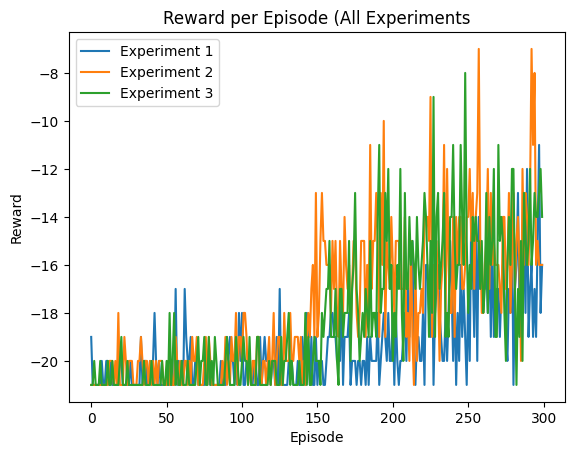

In [6]:


def parse_log(file_path):
    experiments = []
    current_rewards = []

    with open(file_path, "r") as f:
        for line in f:
            if "Episode 0 " in line and current_rewards:
                experiments.append(current_rewards)
                current_rewards = []

            match = re.search(r"Reward (-?\d+\.?\d*)", line)
            if match:
                reward = float(match.group(1))
                current_rewards.append(reward)
    if current_rewards:
        experiments.append(current_rewards)

    return experiments

experiments = parse_log("logs/dqn.log")

#  Plot all 3 experiments
plt.figure()

for i, exp in enumerate(experiments):
    plt.plot(exp, label=f"Experiment {i+1}")

plt.title("Reward per Episode (All Experiments")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()
#


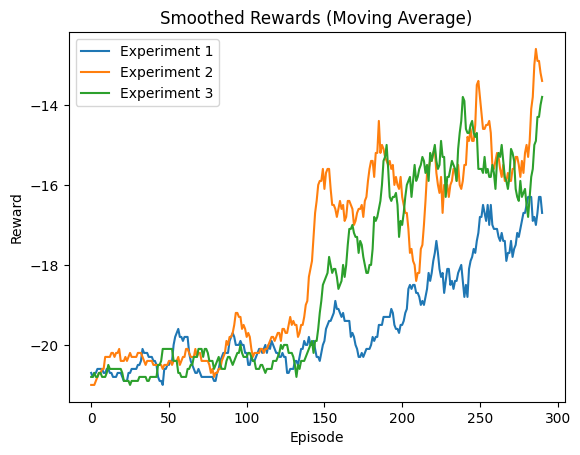

In [7]:
def moving_avg(data, window=10):
    return np.convolve(data, np.ones(window) / window, mode="valid")
plt.figure()

for i, exp in enumerate(experiments):
    smoothed = moving_avg(exp)
    plt.plot(smoothed, label=f"Experiment {i+1}")

plt.title("Smoothed Rewards (Moving Average)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


# 9. Visualize the Agent

After training, the agent is evaluated by allowing it to play the game in a rendered environment

In this evaluation:
- The exploration rate (ε) is set to 0, which means the agent acts greedily
- The agent always selects the action with the highest predicted Q-value

This ensures that the behavior observed reflects the learned policy instead of random exploration

This visualization is to see what the agent has learned meaningful strategies and basically shows  the exploitation phase

In [21]:
def play(agent, episodes=3):

    agent.epsilon = 0

    for ep in range(episodes):
        state,_ = render_env.reset()
        state = np.array(state)
        frames = deque(maxlen=4)
        state, frames = stack_frames(frames, state, True)

        done = False
        total = 0

        while not done:
            render_env.render()

            action = agent.act(state)

            ns, r, term, trunc,_ = render_env.step(action)
            done = term or trunc

            ns, frames = stack_frames(frames, ns, False)
            state = ns
            total += r

        print(f"Simulation Episode {ep} Score {total}")

In [22]:
play(agent_8)

Simulation Episode 0 Score -21.0
Simulation Episode 1 Score -21.0


KeyboardInterrupt: 

# 11. Final Network Architecture

A Deep Q-Network (DQN) was used and is a Convolutional Neural Network (CNN) designed to process visual input from the Pong environment and approximate the Q-function


### Input Representation
The input to the network consists of four consecutive preprocessed frames, stacked together to capture motion information. Each frame has a resolution of 84 x80, resulting in an input shape of:

(84 x 80, 4)

### Convolutional Layers
The network uses three layers to extract spatial features from the inpt:

1. **Conv Layer 1**
   - 32 filters
   - Kernel size: 8 × 8
   - Stride: 4
   - Activation: ReLU

2. **Conv Layer 2**
   - 64 filters
   - Kernel size: 4 × 4
   - Stride: 2
   - Activation: ReLU

3. **Conv Layer 3**
   - 64 filters
   - Kernel size: 3 × 3
   - Stride: 1
   - Activation: ReLU

These layers slowly reduce the spatial dimensions while learning important visual features such as paddle position and ball trajectory



### Fully Connected layers

The output layers of the convolutional layers is flattened which is to say we convert the multi dimensional feature map into a one dimensional vector and passed through two fully connected layers:

- Dense layer with 512 units and ReLU activation
- Output layer with size equal to the number of possible actions

The final output represents the Q-values for each possible action, which shows the expected future reward of taking each action in the given state.



### Output Layer

The network outputs a vector of Q-values:

Q(s, a₁), Q(s, a₂), ..., Q(s, aₙ)

where each valuye corresponds to one of the available actions in the Pong environment

The agent selects actions using an ε-greedy policy, choosing the action with the highest Q-value during exploitation



# 12. Observations & Analysis

- Across all three experiments, the agent initially performs very poorly, with average rewards close to -21, this shows near-random gameplay. Over time, all the different configurations show some sort of improvement which confirms that the agent is learning meaningful policies.

- Experiment 1 demonstrates gradual improvement, ending around an average reward of approximately -16. While learning occurs, the progress is slow and unstable, suggesting inefficient parameter settings.

- Experiment 2 shows the best improvement out of all 3, it reached an average reward near -11. This configuration shows faster convergence and the most stable performance, indicating that the chosen batch size and target update frequency effectively balance learning stability and adaptability.

-  Experiment 3 also improves over time but converges to a lower performance level -14. The learning was less consistent, with higher variance in rewards. If more episodes were involved in training experiment 3 could have overtaken experiment 2 in being the best in terms of average rewards.

# 13. Best Hyperparameters

- Based on the factors evaluated which are; speed, stability, and final performance, the best configuration is: Experiment 2(Batch Size =16, Target Update = 10)

- The combination achieved:
    - The highest average reward (-11)
    - Faster learning compared to the other configurations
    -  More stable convergence with less variance

    The improved performance may suggest that:
    - A moderate batch size provides stable gradient updates
    - A balanced target update frequency prevents instability while allowing learning to adapt